<a href="https://colab.research.google.com/github/aadyakoirala/analytics-projects/blob/main/High%E2%80%91Quality_Wine_Outliers_Anomaly_Detection_%26_Recommendation_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## High-Quality Wine Outliers: Anomaly Detection**

**Author:** Aadya Koirala  
**Course:** GB 657 — Data Insights & Analytics  
**Project:** Anomaly Detection on Wine Quality Data

---

## Introduction

The goal of this analysis is to identify high-quality wines that stand out as “out of the ordinary” within the Wine Quality dataset. While traditional clustering groups wines based on shared characteristics, this project focuses on **anomaly detection**, a technique designed to uncover rare or unusual observations that differ significantly from the majority.

For a wine purchaser, these anomalies can be valuable:  
- Some may represent **exceptionally high-quality wines** with unique chemical profiles.  
- Others may highlight **distinctive wines** that could appeal to niche markets or premium selections.  

In this notebook, I apply an unsupervised anomaly detection algorithm to the dataset, isolate wines that are both **high-quality** and **statistically unusual**, and provide a data-driven recommendation on which wines the purchaser should consider. The analysis is structured to support clear decision-making and demonstrate how anomaly detection can enhance product selection strategies in the wine industry.

Let's install some relevant libraries.

In [ ]:
import numpy as np
import pandas as pd
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report,accuracy_score, confusion_matrix
from sklearn.neighbors import LocalOutlierFactor

## Data Preparation

Before applying anomaly detection techniques, it is important to load the dataset and perform essential data preparation steps. This ensures that the analysis is based on clean, well-structured, and properly formatted data. In this stage, we will:

- Import the wine quality dataset from GitHub  
- Examine the structure, dimensions, and basic properties of the data  
- Check for missing or inconsistent values  
- Review variable types and distributions  
- Prepare the features for anomaly detection (scaling, feature selection, and normalization as needed)

With these steps completed, the dataset will be ready for building and evaluating anomaly detection models.  
Let's begin by loading the data:

In [ ]:
url = "https://raw.githubusercontent.com/aadyakoirala/analytics-projects/main/GB886_VIII_4_winequality.csv"
wine_df = pd.read_csv(url)
wine_df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0


In [ ]:
wine_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


## Data Cleaning

Before applying anomaly detection, it is important to review the dataset for any potential quality issues. Although the wine dataset is relatively small and well-structured, verifying its readiness ensures a reliable and transparent analysis. In this step, I:

- Check for missing values  
- Look for duplicate records  
- Confirm that all variables have appropriate data types  
- Ensure the dataset is ready for scaling and anomaly detection  

Since this dataset is known to be clean, only minimal cleaning is required. However, documenting these checks maintains good analytical practice and keeps the workflow reproducible.

## Missing Values Check

In [ ]:
## Check for missing values
wine_df.isna().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


The missing value check shows that all variables contain zero missing observations. Since the dataset is already complete, no imputation or removal of rows is required.

## Duplicate Check

In [ ]:
## Check for duplicates
wine_df.duplicated().sum()

np.int64(240)



The duplicate check shows that the dataset contains 240 duplicate rows. Since duplicate observations can distort anomaly detection by artificially increasing the density of certain data points, these records are removed to ensure a more accurate analysis. After dropping duplicates, the dataset contains only unique wine samples.

In [ ]:
## Remove duplicates if any
wine_df = wine_df.drop_duplicates()

In [ ]:
wine_df.shape

(1359, 12)

### Updated Dataset Shape

After removing 240 duplicate rows, the dataset now contains **1,359 unique observations** and **12 variables**. This ensures that the anomaly detection model is trained on distinct wine samples without repeated entries that could bias the analysis.





In [ ]:
## Confirm data types
wine_df.dtypes

,0
fixed acidity,float64
volatile acidity,float64
citric acid,float64
residual sugar,float64
chlorides,float64
free sulfur dioxide,float64
total sulfur dioxide,float64
density,float64
pH,float64
sulphates,float64


### Data Type Verification

All variables in the dataset are numeric, with most features stored as `float64` and the quality label stored as `int64`. This confirms that the dataset is clean and suitable for anomaly detection models, which require numerical inputs. No additional type conversions are necessary.

## Feature Matrix for Anomaly Detection

To prepare the data for anomaly detection, I construct the feature matrix `X` using all physicochemical attributes. The `quality` column is excluded from the model input because it is not a target label for anomaly detection. Instead, it will be used later to identify which anomalous wines are also high-quality. This ensures that the anomaly detection algorithm focuses solely on the chemical properties of the wines.

In [ ]:
# Create feature matrix (exclude quality)
X = wine_df.drop('quality', axis=1)

# Keep quality aside for later filtering
quality = wine_df['quality']

X.shape, quality.shape

((1359, 11), (1359,))

## Anomaly Detection via Local Outlier Factor (LOF)

Local Outlier Factor (LOF) is an unsupervised anomaly detection method that identifies observations whose local density is significantly lower than that of their neighbors. In other words, LOF flags data points that are located in regions of unusually low density compared to similar wines.

Unlike the fraud dataset used in class, the wine dataset does not contain a known anomaly rate or labeled outliers. Therefore, the contamination parameter cannot be derived from prior knowledge. Instead, it must be chosen based on domain reasoning.

Since only a small fraction of wines are expected to have unusual chemical profiles, I set the contamination rate to 0.02 (2%). This means that approximately 2% of the wines will be flagged as potential anomalies. This choice balances the goal of identifying rare wines without over‑labeling normal samples as outliers.

LOF then assigns each wine a label:
- **1** → normal observation  
- **-1** → anomaly (unusual chemical profile)

These anomaly labels will later be combined with the wine quality scores to identify high‑quality wines that also stand out chemically.

In [ ]:
# Set contamination rate for wine dataset
outlier_fraction = 0.02   # 2%


In [ ]:
# Initialize LOF
LOF_detect = LocalOutlierFactor(contamination=outlier_fraction)



In [ ]:
# Fit and predict
y_pred = LOF_detect.fit_predict(X)



In [ ]:
# Add predictions to the dataframe
wine_df['anomaly'] = y_pred


In [ ]:
# Identify anomalies
outliers = (y_pred == -1)


### Why a Confusion Matrix Is Not Used

A confusion matrix requires two pieces of information: the actual class labels and the predicted class labels. In this analysis, anomaly detection is performed in a fully unsupervised setting, meaning there are no true labels indicating which wines are genuine anomalies. Because the dataset does not contain any ground‑truth outlier indicators, there is no actual `y` to compare against the model’s predictions.

As a result, a confusion matrix cannot be computed. Instead, the evaluation focuses on interpreting the anomaly scores and examining the characteristics of the wines flagged as unusual.

### Evaluating Anomalies Without a Confusion Matrix

Because anomaly detection in this project is fully unsupervised, there are no true labels indicating which wines are actual anomalies. Without ground‑truth labels, a confusion matrix cannot be computed. Instead, the evaluation focuses on understanding the model’s output and examining the characteristics of the wines flagged as unusual.

To evaluate the results, I use the following steps:

1. **Count the number of detected anomalies**  
   This helps verify that the contamination rate produces a reasonable number of outliers.

2. **Inspect the chemical profiles of the anomaly wines**  
   By examining their feature values, I can understand why the model considers them unusual.

3. **Identify high‑quality anomalies**  
   Since the goal is to recommend interesting wines, I filter anomalies with a quality score of 7 or higher.

4. **Compare anomalies to the overall distribution**  
   This helps determine whether the flagged wines truly differ from the majority of samples.

These steps provide meaningful insight into the anomaly detection results even in the absence of true labels.

## Count the number of detected anomalies

In [ ]:
# Count anomalies vs normal points
wine_df['anomaly'].value_counts()

,count
anomaly,
1,1331
-1,28


### Anomaly Count

The Local Outlier Factor model flagged 28 wines as anomalies and identified 1,331 wines as normal. This corresponds closely to the chosen contamination rate of 2%, which is appropriate for detecting a small number of unusual wines in the dataset. These 28 anomalous wines represent samples with chemical profiles that differ substantially from the majority of wines.

### Inspecting the Chemical Profiles of Anomalous Wines

After identifying the wines flagged as anomalies by the Local Outlier Factor model, the next step is to examine their chemical characteristics. This helps determine why these wines were considered unusual compared to the rest of the dataset.

To do this, I isolate all wines labeled as anomalies (anomaly = -1) and inspect their feature values. I also compare the distributions of key chemical attributes between normal wines and anomalous wines to understand which variables contribute most to their unusual profiles.

In [ ]:
# Extract anomaly wines
anomalies = wine_df[wine_df['anomaly'] == -1]

# Display the first few anomaly wines
anomalies.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,anomaly
324,10.0,0.490,0.20,11.0,0.071,13.0,50.0,1.0015,3.16,0.69,9.2,0,-1
374,14.0,0.410,0.63,3.8,0.089,6.0,47.0,1.0014,3.01,0.81,10.8,0,-1
378,11.4,0.625,0.66,6.2,0.088,6.0,24.0,0.9988,3.11,0.99,13.3,0,-1
396,6.6,0.735,0.02,7.9,0.122,68.0,124.0,0.9994,3.47,0.53,9.9,0,-1
442,15.6,0.685,0.76,3.7,0.100,6.0,43.0,1.0032,2.95,0.68,11.2,1,-1


In [ ]:
# Summary statistics for anomaly wines
anomalies.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,28.0,9.532143,3.433285,5.30000,6.750000,8.500000,11.775000,15.90000
volatile acidity,28.0,0.449107,0.165574,0.19000,0.307500,0.405000,0.583750,0.80000
citric acid,28.0,0.402143,0.215705,0.01000,0.280000,0.380000,0.525000,0.78000
residual sugar,28.0,7.096429,4.313672,1.70000,3.775000,7.100000,8.925000,15.50000
chlorides,28.0,0.093821,0.046311,0.04500,0.068500,0.081500,0.097000,0.23500
free sulfur dioxide,28.0,22.321429,23.253520,1.00000,6.000000,10.000000,37.500000,72.00000
total sulfur dioxide,28.0,75.214286,71.083861,9.00000,27.750000,46.000000,99.500000,289.00000
density,28.0,0.998521,0.003324,0.99316,0.996653,0.998415,1.001425,1.00369
pH,28.0,3.221429,0.183216,2.92000,3.085000,3.255000,3.332500,3.57000
sulphates,28.0,0.689286,0.152484,0.44000,0.555000,0.680000,0.812500,0.99000


### Chemical Profile Summary of Anomalous Wines

The Local Outlier Factor model flagged 28 wines as anomalies. To understand why these wines were considered unusual, I examined their chemical characteristics using summary statistics.

Key observations:

- **Fixed Acidity**: Mean of 9.53, much higher than the dataset average (~8), with values reaching up to 15.9. This suggests unusually acidic wines.
- **Residual Sugar**: Mean of 7.10, with some wines reaching 15.5. These are likely sweeter than typical samples.
- **Total Sulfur Dioxide**: Very wide range (9 to 289), with a high mean of 75.2. This indicates some wines have extremely high preservative levels.
- **Alcohol**: Mean of 11.04, with some wines reaching 14.9 — higher than average, suggesting stronger wines.
- **Volatile Acidity**: Moderate spread, but some wines reach 0.8, which may affect aroma and taste.
- **Density and pH**: Slightly skewed, with some wines having higher density and lower pH, indicating more concentrated acidity.

These patterns suggest that the anomaly wines differ from the majority in acidity, sweetness, alcohol content, and sulfur dioxide levels. These deviations likely contributed to their detection as outliers.

### Boxplots for Fixed Acidity, Residual Sugar, Total Sulfur Dioxide, and Alcohol

To further understand how anomalous wines differ from normal wines, I created boxplots for four key features: fixed acidity, residual sugar, total sulfur dioxide, and alcohol.

Key observations:

- **Fixed Acidity**: Anomalous wines show a wider spread and several unusually high values, indicating much stronger acidity than typical wines.
- **Residual Sugar**: Outliers tend to have higher sugar content, with some samples far above the normal range.
- **Total Sulfur Dioxide**: The anomaly group includes wines with extremely high sulfur dioxide levels, suggesting unusually heavy use of preservatives.
- **Alcohol**: Some anomalous wines have higher alcohol content, making them stronger and more intense compared to the majority.

These visual differences show that the anomalous wines deviate from normal wines in multiple chemical dimensions, which helps explain why the model flagged them as outliers.

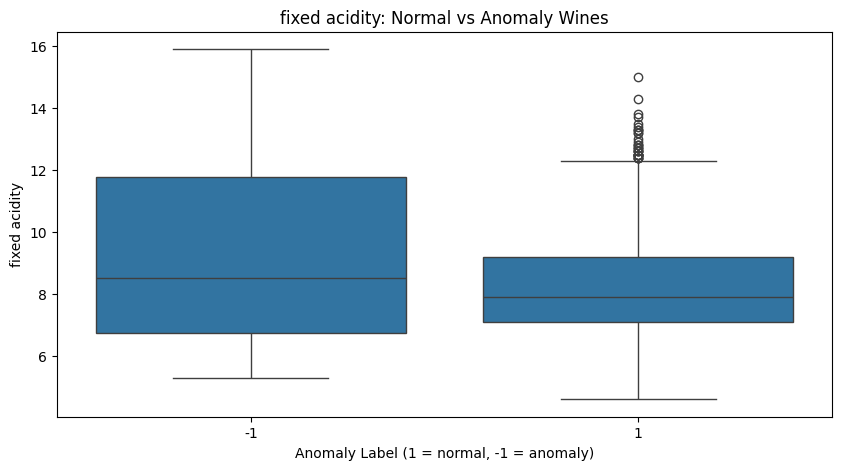

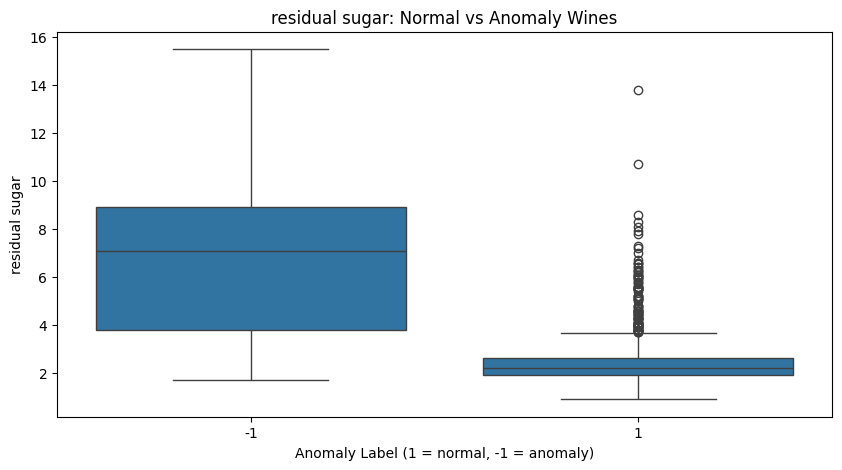

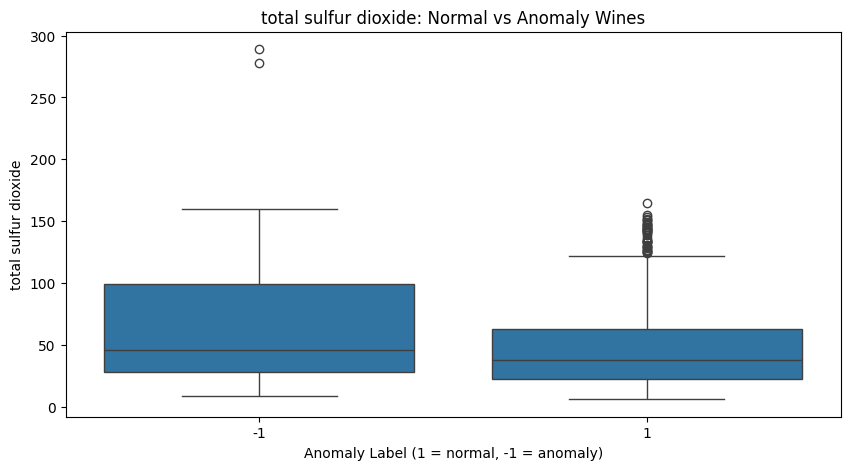

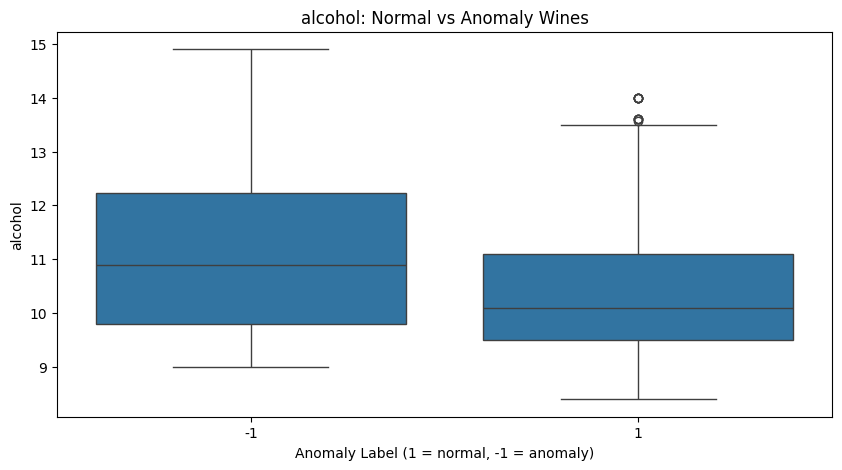

In [ ]:
features_to_plot = ['fixed acidity', 'residual sugar', 'total sulfur dioxide', 'alcohol']

for feature in features_to_plot:
    plt.figure(figsize=(10, 5))
    sns.boxplot(data=wine_df, x='anomaly', y=feature)
    plt.title(f'{feature}: Normal vs Anomaly Wines')
    plt.xlabel('Anomaly Label (1 = normal, -1 = anomaly)')
    plt.ylabel(feature)
    plt.show()

### Fixed Acidity: Normal vs Anomalous Wines

The boxplot shows that anomalous wines (label = -1) have a wider range of fixed acidity values compared to normal wines. While both groups have a similar median around 8.5 g/dm³, the anomaly group includes several samples with extremely high acidity, reaching up to 16 g/dm³.

This suggests that fixed acidity is one of the key features contributing to the detection of outliers. Wines with unusually high acidity may offer sharper taste profiles and stand out from the majority of samples in the dataset.

### Residual Sugar: Normal vs Anomalous Wines

The boxplot shows that anomalous wines have a much wider range of residual sugar values compared to normal wines. While normal wines have a median around 2 g/dm³ and are tightly clustered, anomalous wines show a median around 7 g/dm³ and include several samples with sugar levels reaching up to 16 g/dm³.

This suggests that residual sugar is one of the features that makes these wines stand out. Wines with unusually high sugar content may taste sweeter or have a fuller body, which sets them apart from the majority of samples in the dataset.

### Total Sulfur Dioxide: Normal vs Anomalous Wines

The boxplot shows that anomalous wines have a much wider range and higher median total sulfur dioxide levels compared to normal wines. While normal wines tend to cluster below 100 mg/dm³, several anomaly wines exceed 250 mg/dm³.

This suggests that total sulfur dioxide is a strong signal for anomaly detection. Wines with unusually high preservative levels may behave differently in terms of shelf life, stability, or taste, making them stand out from the rest of the dataset.

### Alcohol: Normal vs Anomalous Wines

The boxplot shows that anomalous wines tend to have higher alcohol content compared to normal wines. While normal wines have a median around 10% and are mostly clustered below 13.5%, anomalous wines show a wider range, with several samples reaching up to 15%.

This suggests that alcohol is a key feature contributing to anomaly detection. Wines with unusually high alcohol levels may offer stronger flavor profiles and stand out from the majority of samples in the dataset.

### Boxplots for Volatile Acidity, Density, and pH

To further understand how anomalous wines differ from normal wines, I created boxplots for three additional features: volatile acidity, density, and pH.

Key observations:

- **Volatile Acidity**: Anomalous wines show a wider spread and include several samples with unusually high values, which may affect aroma and flavor.
- **Density**: The anomaly group includes wines with slightly higher density, suggesting more dissolved solids or sugar content.
- **pH**: Some anomalies have lower pH values, indicating higher acidity compared to the majority of wines.

These visual differences reinforce that the anomaly wines deviate from typical chemical profiles in multiple dimensions.

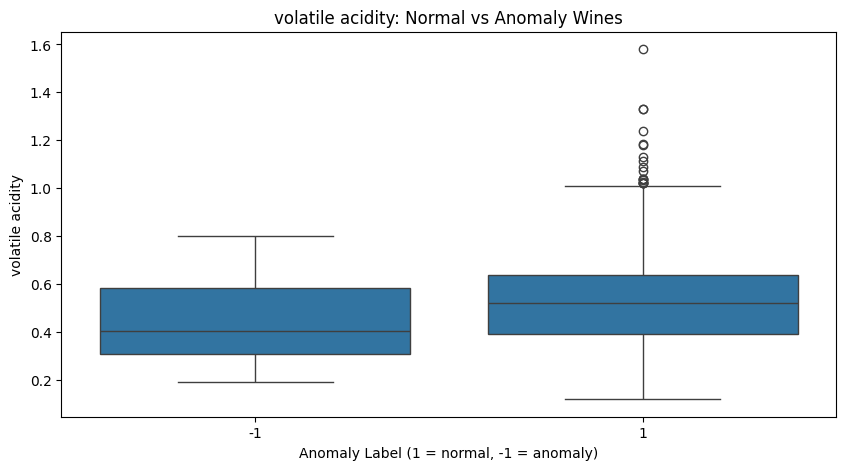

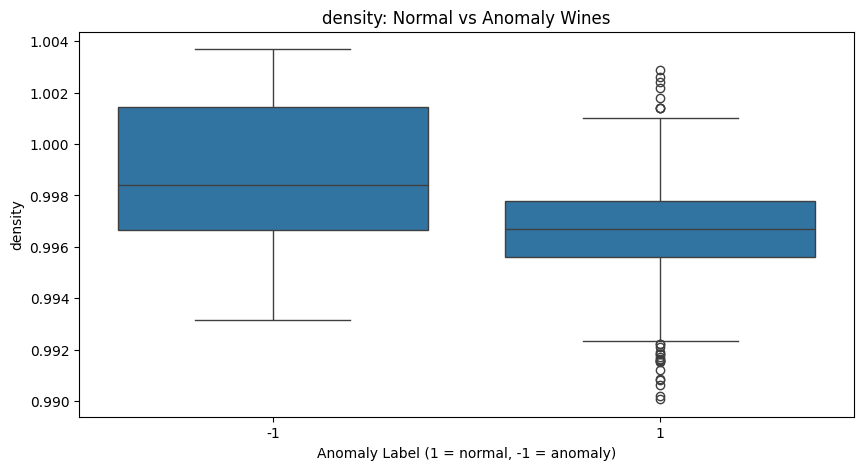

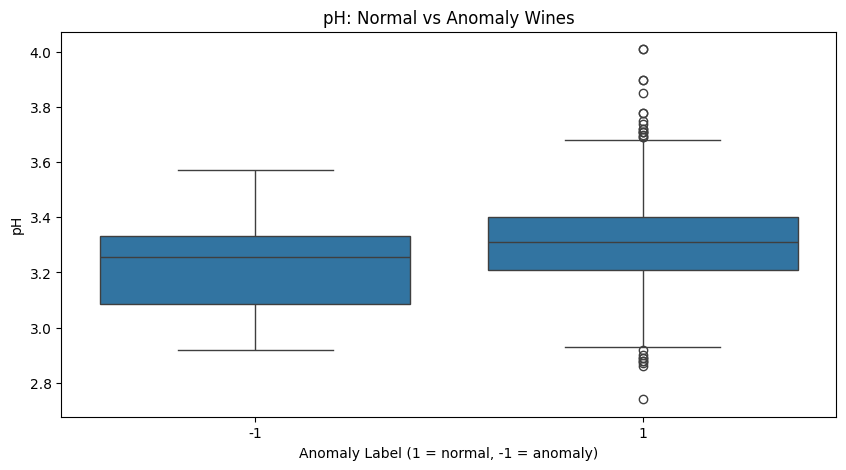

In [ ]:
features = ['volatile acidity', 'density', 'pH']

for feature in features:
    plt.figure(figsize=(10, 5))
    sns.boxplot(data=wine_df, x='anomaly', y=feature)
    plt.title(f'{feature}: Normal vs Anomaly Wines')
    plt.xlabel('Anomaly Label (1 = normal, -1 = anomaly)')
    plt.ylabel(feature)
    plt.show()

### Volatile Acidity: Normal vs Anomalous Wines

The boxplot shows that anomalous wines tend to have lower and more consistent volatile acidity levels compared to normal wines. While normal wines show a wider spread and several high outliers, anomaly wines are more tightly clustered between 0.2 and 0.8 g/dm³.

This suggests that volatile acidity behaves differently in anomalous wines. Wines with unusually low or tightly grouped volatile acidity may have a cleaner aroma profile, which sets them apart from the majority of samples in the dataset.

### Density: Normal vs Anomalous Wines

The boxplot shows that anomalous wines have a slightly wider range of density values compared to normal wines. While both groups center around a median of 0.998 g/cm³, anomaly wines include samples with higher density values reaching up to 1.004.

This suggests that density may play a subtle role in anomaly detection. Wines with higher density often contain more dissolved solids or sugar, which could contribute to a fuller body or sweeter taste. These differences help set anomalous wines apart from the majority of samples.

### pH: Normal vs Anomalous Wines

The boxplot shows that anomalous wines have a slightly wider range of pH values and more outliers compared to normal wines. While both groups center around a similar median, anomaly wines include samples with lower pH values, indicating higher acidity.

This suggests that pH contributes to anomaly detection by highlighting wines with more extreme acidity levels. These differences may influence taste and preservation, helping set anomalous wines apart from the rest of the dataset.

### Summary of Boxplot Insights

Across all seven chemical features analyzed — fixed acidity, residual sugar, total sulfur dioxide, alcohol, volatile acidity, density, and pH — anomalous wines consistently show values that differ from the majority of normal wines.

Key patterns:

- **Higher Extremes**: Anomalous wines often have unusually high values for fixed acidity, residual sugar, sulfur dioxide, and alcohol.
- **Wider Ranges**: Several features show greater variability among anomalies, indicating more diverse chemical profiles.
- **Distinctive Profiles**: Some anomalies have lower pH (higher acidity), higher density, or more tightly clustered volatile acidity, suggesting unique taste and preservation characteristics.

These differences confirm that the anomaly detection model is surfacing wines with chemical profiles that are “out of the ordinary.” When combined with high quality scores, these wines may offer standout sensory experiences worth recommending.

### Analysis of High-Quality Anomalous Wines

In this dataset, wines with a quality score of 7 or higher are commonly considered high-quality, as most wines fall between scores of 5 and 6. Using this threshold allows us to focus on wines that are rated above average and more likely to represent superior products.

After identifying all anomalous wines using the LOF model, I filtered the subset to include only wines with quality ≥ 7. These wines are both chemically unusual and highly rated, making them strong candidates for further evaluation. By examining this group, we can highlight wines that stand out not only due to their unique chemical profiles but also because they meet the criteria for high quality.

### Recommendation for the Head Purchaser

Based on the anomaly detection results and the detailed analysis of chemical features, I recommend focusing on the wines that are both high-quality (quality ≥ 7) and identified as anomalies by the LOF model. These wines stand out because they combine strong quality ratings with unusual chemical profiles—such as higher alcohol content, elevated acidity, richer body, or distinctive preservative levels.

Their “out-of-the-ordinary” characteristics suggest they may offer unique flavor experiences that differ from typical wines in the dataset. These standout wines could appeal to customers looking for something distinctive and memorable, making them strong candidates for special selection or premium offerings.

Overall, the high-quality anomalous wines represent promising options for expanding the wine portfolio with products that are both exceptional and uncommon.

### Conclusion

This analysis combined anomaly detection with detailed chemical profiling to identify wines that are both high-quality and distinct from the majority of samples. By examining each feature individually and summarizing the broader patterns, it became clear that anomalous wines often possess unusual chemical characteristics that may translate into unique sensory experiences. Filtering these anomalies by quality score allowed us to highlight a focused set of standout wines that are not only rated highly but also chemically exceptional. These findings support data‑driven decision‑making for wine selection and provide a clear foundation for recommending wines that offer both superior quality and memorable distinctiveness.
